In [25]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler

cols = ['duration','protocol_type','service','flag','src_bytes','dst_bytes','land','wrong_fragment','urgent','hot','num_failed_logins','logged_in','num_compromised','root_shell','su_attempted','num_root','num_file_creations','num_shells','num_access_files','num_outbound_cmds','is_host_login','is_guest_login','count','srv_count','serror_rate','srv_serror_rate','rerror_rate','srv_rerror_rate','same_srv_rate','diff_srv_rate','srv_diff_host_rate','dst_host_count','dst_host_srv_count','dst_host_same_srv_rate','dst_host_diff_srv_rate','dst_host_same_src_port_rate','dst_host_srv_diff_host_rate','dst_host_serror_rate','dst_host_srv_serror_rate','dst_host_rerror_rate','dst_host_srv_rerror_rate','label','difficulty']
df_train = pd.read_csv('data/KDDTrain+.txt', header=None, names=cols)
df_test = pd.read_csv('data/KDDTest+.txt', header=None, names=cols)
print(df_train.shape, df_test.shape)


(125973, 43) (22544, 43)


In [26]:
y_train = (df_train['label'] != 'normal').astype(int)
y_test = (df_test['label'] != 'normal').astype(int)


In [27]:
df_all = pd.concat([df_train, df_test], axis=0)
df_all = pd.get_dummies(df_all, columns=['protocol_type','service','flag'])
df_train = df_all.iloc[:125973].copy()
df_test = df_all.iloc[125973:].copy()


In [28]:
X_train = df_train.drop(['label','difficulty'], axis=1)
X_test = df_test.drop(['label','difficulty'], axis=1)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
print(X_train_scaled.shape, X_test_scaled.shape)


(125973, 122) (22544, 122)


In [29]:
from sklearn.ensemble import RandomForestClassifier
rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf.fit(X_train_scaled, y_train)
y_pred = rf.predict(X_test_scaled)


In [30]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
print("准确率:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred, target_names=['正常', '攻击']))
print(confusion_matrix(y_test, y_pred))


准确率: 0.7647711142654364
              precision    recall  f1-score   support

          正常       0.65      0.97      0.78      9711
          攻击       0.97      0.61      0.75     12833

    accuracy                           0.76     22544
   macro avg       0.81      0.79      0.76     22544
weighted avg       0.83      0.76      0.76     22544

[[9445  266]
 [5037 7796]]


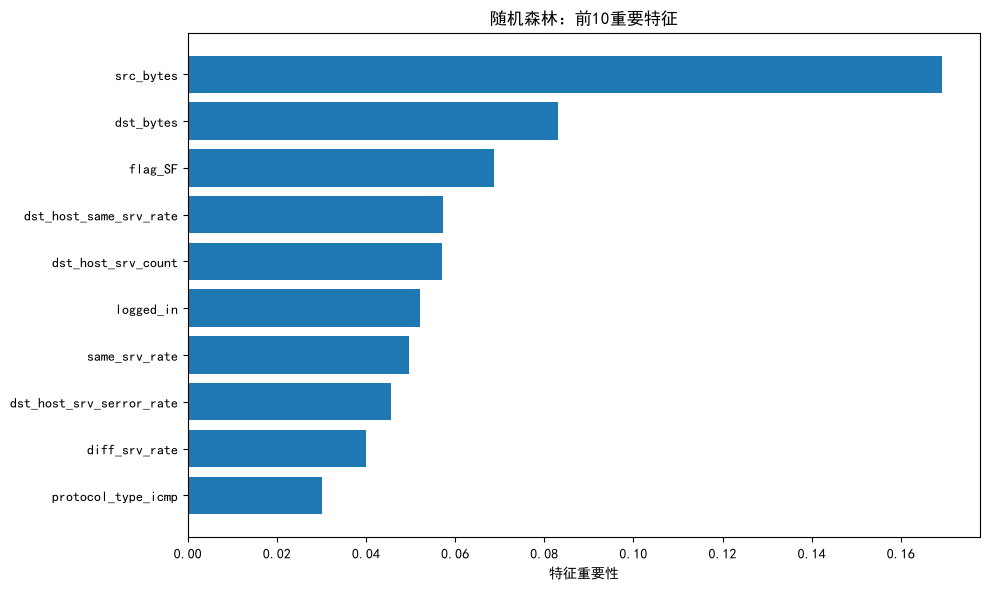

In [31]:
import matplotlib.pyplot as plt
plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False

importances = rf.feature_importances_
feat_names = list(X_train.columns)
top10_idx = np.argsort(importances)[-10:]

plt.figure(figsize=(10, 6))
plt.barh(range(10), importances[top10_idx])
plt.yticks(range(10), [feat_names[i] for i in top10_idx])
plt.xlabel('特征重要性')
plt.title('随机森林：前10重要特征')
plt.tight_layout()
plt.show()


In [32]:
from sklearn.linear_model import LogisticRegression
lr = LogisticRegression(max_iter=1000)
lr.fit(X_train_scaled, y_train)
y_pred_lr = lr.predict(X_test_scaled)
print("LR准确率:", accuracy_score(y_test, y_pred_lr))
print(classification_report(y_test, y_pred_lr, target_names=['正常', '攻击']))


LR准确率: 0.7535486160397445
              precision    recall  f1-score   support

          正常       0.65      0.93      0.76      9711
          攻击       0.92      0.62      0.74     12833

    accuracy                           0.75     22544
   macro avg       0.78      0.77      0.75     22544
weighted avg       0.80      0.75      0.75     22544



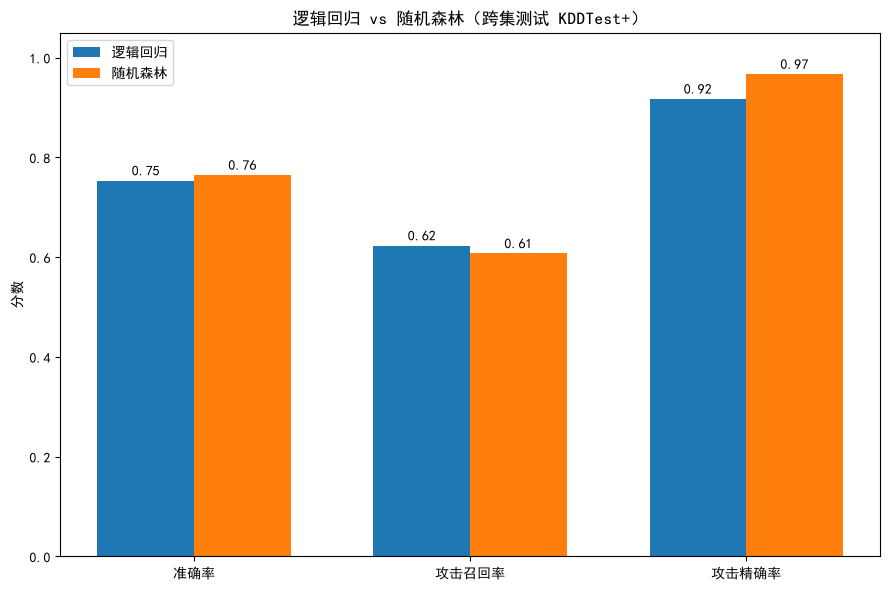

In [33]:
lr_report = classification_report(y_test, y_pred_lr, target_names=['正常', '攻击'], output_dict=True)
rf_report = classification_report(y_test, y_pred, target_names=['正常', '攻击'], output_dict=True)

metrics = ['准确率', '攻击召回率', '攻击精确率']
lr_scores = [accuracy_score(y_test, y_pred_lr), lr_report['攻击']['recall'], lr_report['攻击']['precision']]
rf_scores = [accuracy_score(y_test, y_pred), rf_report['攻击']['recall'], rf_report['攻击']['precision']]

x = np.arange(len(metrics))
width = 0.35
plt.figure(figsize=(9, 6))
plt.bar(x - width/2, lr_scores, width, label='逻辑回归')
plt.bar(x + width/2, rf_scores, width, label='随机森林')
plt.xticks(x, metrics)
plt.ylim(0, 1.05)
plt.ylabel('分数')
plt.title('逻辑回归 vs 随机森林（跨集测试 KDDTest+）')
plt.legend()
for i, v in enumerate(lr_scores):
    plt.text(i - width/2, v + 0.01, f'{v:.2f}', ha='center')
for i, v in enumerate(rf_scores):
    plt.text(i + width/2, v + 0.01, f'{v:.2f}', ha='center')
plt.tight_layout()
plt.show()
